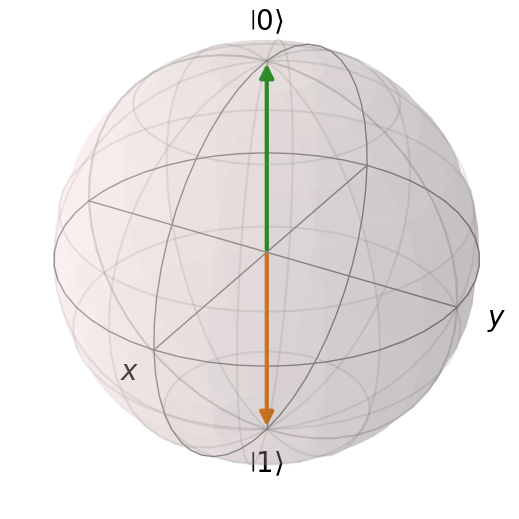

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from qutip import Bloch, basis

# Qutip test
# create Bloch sphere
b = Bloch()
# define basis states
ket_0 = basis(2, 0)
ket_1 = basis(2, 1)
# add basis states to Bloch sphere

b.add_states([ket_0, ket_1])
b.show()

In [3]:
# Qiskit test
from qiskit import QuantumCircuit

# make circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.p(np.pi / 2, 0) # phase
qc.cx(0, 1)
qc.cx(0, 2)

# define observable to be measured 
from qiskit.quantum_info import SparsePauliOp
operator = SparsePauliOp.from_list([("XXY", 1), ("XYX", 1), ("YXX", 1), ("YYY", -1)])

# execute using Estimator primitive
from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()
job = estimator.run([(qc, operator)], precision = 1e-3)
result = job.result()
print(f" > Expectation values: {result[0].data.evs}")

 > Expectation values: 4.000315559155871


Vacuum Rabi oscillations in the Jaynes-Cummings model

In [4]:
import matplotlib.pyplot as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (about, basis, destroy, mesolve, ptrace, qeye, tensor, wigner, anim_wigner)
from matplotlib import rc
rc("animation", html = "jshtml")
%matplotlib inline

In [5]:
wc = 1.0 * 2 * np.pi  # cavity frequency
wa = 1.0 * 2 * np.pi  # atom frequency
g = 0.05 * 2 * np.pi  # coupling strength
kappa = 0.005  # cavity dissipation rate
gamma = 0.05  # atom dissipation rate
N = 15  # number of cavity fock states
n_th_a = 0.0  # avg number of thermal bath excitation
use_rwa = True

tlist = np.linspace(0, 25, 101)

In [6]:
# initial state 
psi0 = tensor(basis(N, 0), basis(2, 1)) # tensor product of ground state with first excited state

# operators
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2))

# Hamiltonian
if use_rwa:
    H = wc * a.dag() * a + wa * sm.dag() * sm + \
        g * (a.dag() * sm + a * sm.dag())
else:
    H = wc * a.dag() * a + wa * sm.dag() * sm + \
        g * (a.dag() + a) * (sm + sm.dag())

In [7]:
# COLLAPSE OPERATORS
c_ops = []

# cavity relaxation (photons escaping cavity)
rate = kappa * (1 + n_th_a)
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a)

# cavity excitation, if temperature > 0
rate = kappa * n_th_a
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a.dag())

# qubit relaxation
rate = gamma
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * sm)

In [8]:
output = mesolve(H, psi0, tlist, c_ops, e_ops=[a.dag() * a, sm.dag() * sm])
print(output)

#sm.dag() expectation value, probability atom is excited

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0009961128234863281
    preparation time: 0.004749774932861328
    run time: 0.022893905639648438
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 25.0] (101 steps)
  Number of e_ops: 2
  State not saved.
>


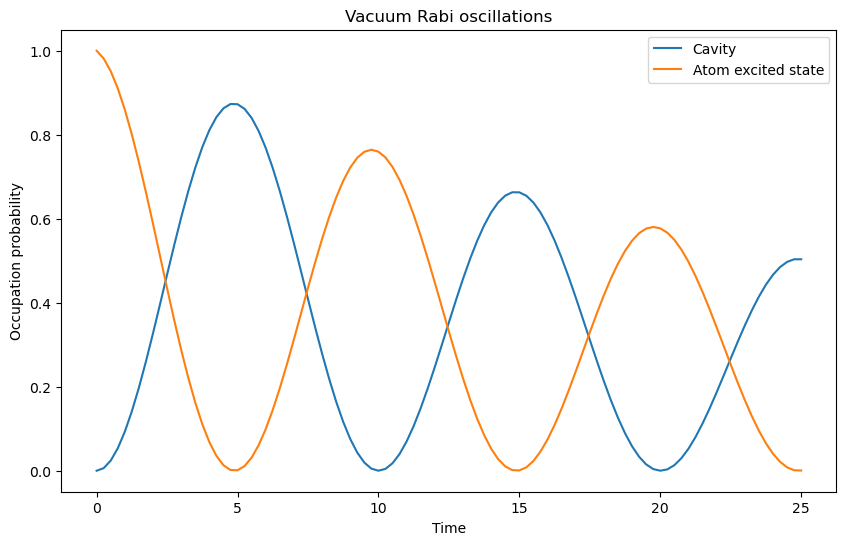

In [9]:
n_c = output.expect[0]
n_a = output.expect[1]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(tlist, n_c, label="Cavity")
axes.plot(tlist, n_a, label="Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi oscillations");

plt.show()

In [10]:
output = mesolve(H, psi0, tlist, c_ops)

In [11]:
output

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0
    preparation time: 0.0
    run time: 0.02443099021911621
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 25.0] (101 steps)
  Number of e_ops: 0
  States saved.
>

In [12]:
# indexing the list with -1 results in the last element in the list
output.states[-1]

# Wigner function: kind of a probability distribution

Quantum object: dims=[[15, 2], [15, 2]], shape=(30, 30), type='oper', dtype=Dense, isherm=True
Qobj data =
[[4.96058553e-01+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j        ]
 [0.00000000e+00+0.j         4.81112490e-04+0.j
  0.00000000e+00-0.01549669j 0.00000000e+00+0.j
  0.00000000e+00+0.j         0.00000000e+00+0.j
  0.00000000e+00+0.j

mesolve stands for Master Equation Solver in QuTiP (Quantum Toolbox in Python).
It numerically solves the Lindblad master equation for open quantum systems — i.e., systems that can interact with an environment (decay, dephasing, etc.).

# Introduction to QuTiP

In [14]:
# creating quantum objects
from qutip import Qobj

# quantum states
ket_0 = Qobj([[1], [0]])
ket_1 = Qobj([[0], [1]])

# pauli X
X = Qobj([[0, 1], [1, 0]])

# density matrix for mixed state
rho = Qobj([[0.5, 0], [0, 0.5]])

bra_0 = ket_0.dag()
print(bra_0)
print(bra_0.dims)
print(bra_0.type)
print(bra_0.data)

Quantum object: dims=[[1], [2]], shape=(1, 2), type='bra', dtype=Dense
Qobj data =
[[1. 0.]]
[[1], [2]]
bra
Dense(shape=(1, 2), fortran=False)


In [32]:
# create qubit state
from qutip import basis
from qutip import sigmax, sigmay, sigmaz

ket_0 = basis(2, 0)
ket_1 = basis(2, 1)
X = sigmax()
Y = sigmay()
Z = sigmaz()

new_state = X * ket_0

# compsite system 
from qutip import tensor 
composite_state = tensor(ket_0, ket_1)
print(composite_state)

# inner product 
inner_product = ket_0.dag() * ket_1

# expectation value 
expectation_value = ket_0.dag() * X * ket_0

# overlap
overlap = ket_0.overlap(ket_1)

# matrix representation
rho.data

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]


Dense(shape=(2, 2), fortran=False)

In [21]:
""" time evolution of quantum systems 
different solver methods depending on systems 
results of solver envapsulated in solver.Result class
can access all different results 

visualisation and plotting 
plot_state: plots state vector or density matrix of quantum state
plot_expectation_values: exp vals of operators over time
plot_wigner: wigner function of quantum state
plot_bloch_vector: bloch vector rep of qubit state

WIGNER FUNCTION:
quasi probability function: reps quantum states in phase space
"""

' time evolution of quantum systems \ndifferent solver methods depending on systems \nresults of solver envapsulated in solver.Result class\ncan access all different results \n\nvisualisation and plotting \nplot_state: plots state vector or density matrix of quantum state\nplot_expectation_values: exp vals of operators over time\nplot_wigner: wigner function of quantum state\nplot_bloch_vector: bloch vector rep of qubit state\n\nWIGNER FUNCTION:\nquasi probability function: reps quantum states in phase space\n'

In [26]:
# partial traces
from qutip import ptrace

# compute partial trace over second subsystem
# (trace out second subsystem)
reduced_state = ptrace(composite_state, 0)
print(reduced_state)

"""
Partial trace reduces dimensions of the Hilbert space my eliminating some degrees of freedom by averaging (tracing)
converse of tensor product
useful when interested in only a part of a coupled quantum system
"""

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


'\nPartial trace reduces dimensions of the Hilbert space my eliminating some degrees of freedom by averaging (tracing)\nconverse of tensor product\nuseful when interested in only a part of a coupled quantum system\n'

In [35]:
# superoperators and tensor manipulations 
"""
Superoperators act on other operators
useful for describing dynamics of open quantum systems
"""

from qutip import spre, spost, to_super

# create quantum operator
A = sigmax()
# superoperator that applies A from the left
super_left = spre(A)
# superoperator that applies A from the right
super_right = spost(A)
# convert operator to superoperator
super_A = to_super(A)

In [34]:
# superoperator example: DEPOLARISING CHANNEL
"""
model for quantum noise in quantum systems
can be represented as superoperator acting on qubit density matrix
"""

# depolarising probability
p = 0.1
# identity
I = Qobj(np.eye(2))

# construct depolarising channel superoperator
depolarising_channel = (1 - p) * to_super(I) + (p / 3) * (to_super(X) + to_super(Y) + to_super(Z))
print(depolarising_channel)

Quantum object: dims=[[[2], [2]], [[2], [2]]], shape=(4, 4), type='super', dtype=Dense, isherm=True
Qobj data =
[[0.93333333 0.         0.         0.06666667]
 [0.         0.86666667 0.         0.        ]
 [0.         0.         0.86666667 0.        ]
 [0.06666667 0.         0.         0.93333333]]
